# 04 — Route Profitability Analysis

Reads **only** from the Delta pipeline (Bronze/Silver/Gold) — never the raw CSV —
to prove the pipeline is the source of truth. Every number and chart below is
computed live in this notebook; narrative is written *after* looking at the output.

Uses the underperformance flags **already defined in Silver** (`margin < 10%`,
`underperforming_flag`, `route_persistent_underperformer`) — not a redefinition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
from spark_session import build_spark, delta_path

spark = build_spark("04_profitability_analysis")
silver = spark.read.format("delta").load(delta_path("silver", "route_day_profitability", spark))
gold   = spark.read.format("delta").load(delta_path("gold", "route_month_profitability", spark))
FIG = os.path.abspath("../docs/figures"); os.makedirs(FIG, exist_ok=True)
print("Loaded from Delta — Silver rows:", silver.count(), "| Gold rows:", gold.count())
print("(raw CSV is NOT read in this notebook)")

Loaded from Delta — Silver rows: 12000 | Gold rows: 4035
(raw CSV is NOT read in this notebook)


## 1. Underperforming routes, areas, and BUs

Aggregating the Silver flags up the operational hierarchy. `weighted_margin` =
Σ gross_profit / Σ total_revenue (dollar-weighted, not a mean of day percentages);
`under_pct` = share of that group's route-days flagged `underperforming_flag`.

In [2]:
def hier(col):
    return (silver.groupBy(col)
        .agg(F.count("*").alias("days"),
             F.round(F.sum(F.col("underperforming_flag").cast("int"))/F.count("*")*100,1).alias("under_pct"),
             F.round(F.sum("gross_profit")/F.sum("total_revenue")*100,2).alias("weighted_margin"))
        .orderBy("weighted_margin"))

bu_df   = hier("bu").toPandas()
area_df = hier("area").toPandas()
print("=== By BU (worst first) ==="); print(bu_df.to_string(index=False))
print("\n=== By AREA (worst 10) ==="); print(area_df.head(10).to_string(index=False))

persistent = (silver.filter("route_persistent_underperformer")
              .select("route_id","region","bu","area","route_weighted_margin_pct","route_pct_days_under")
              .distinct().orderBy("route_weighted_margin_pct"))
print(f"\n=== Persistent-underperformer routes: {persistent.count()} of 120 ===")
persistent.show(8, truncate=False)

=== By BU (worst first) ===
                bu  days  under_pct  weighted_margin
        Calgary BU   758       15.4            36.51
             BC BU  1944        5.0            46.64
         Quebec BU  2362        8.9            47.68
       Atlantic BU  2514       14.6            48.31
       Prairies BU  1822        8.1            51.66
       Edmonton BU  1011       10.9            53.72
Central Ontario BU   839       12.0            54.68
            GTA BU   750        8.7            55.60

=== By AREA (worst 10) ===
         area  days  under_pct  weighted_margin
      Airdrie   182       50.5            11.28
        Laval   200       48.5            12.37
     Kingston   102       49.0            12.52
 Toronto East    96       32.3            17.96
Toronto North    89       28.1            20.76
Sherwood Park    99        8.1            36.12
   Calgary SW   198        8.1            36.31
   Abbotsford   405       10.6            40.49
       Surrey   407        3.4     


=== Persistent-underperformer routes: 21 of 120 ===


+--------+--------+-----------+-----------+-------------------------+--------------------+
|route_id|region  |bu         |area       |route_weighted_margin_pct|route_pct_days_under|
+--------+--------+-----------+-----------+-------------------------+--------------------+
|RTE-0114|Alberta |Edmonton BU|St. Albert |-15.278176780353833      |0.875               |
|RTE-0035|Atlantic|Atlantic BU|Fredericton|-12.999868098378997      |0.8878504672897196  |
|RTE-0061|Atlantic|Atlantic BU|Moncton    |-4.549176014494562       |0.7821782178217822  |
|RTE-0059|Prairies|Prairies BU|Regina     |0.8366043536788998       |0.6576576576576577  |
|RTE-0117|Alberta |Calgary BU |Airdrie    |7.251499915999846        |0.5978260869565217  |
|RTE-0081|Quebec  |Quebec BU  |Laval      |9.148674593922788        |0.5803571428571429  |
|RTE-0020|Atlantic|Atlantic BU|Fredericton|9.271962216673742        |0.48514851485148514 |
|RTE-0070|Atlantic|Atlantic BU|Fredericton|9.87772162137527         |0.5148514851485149  |

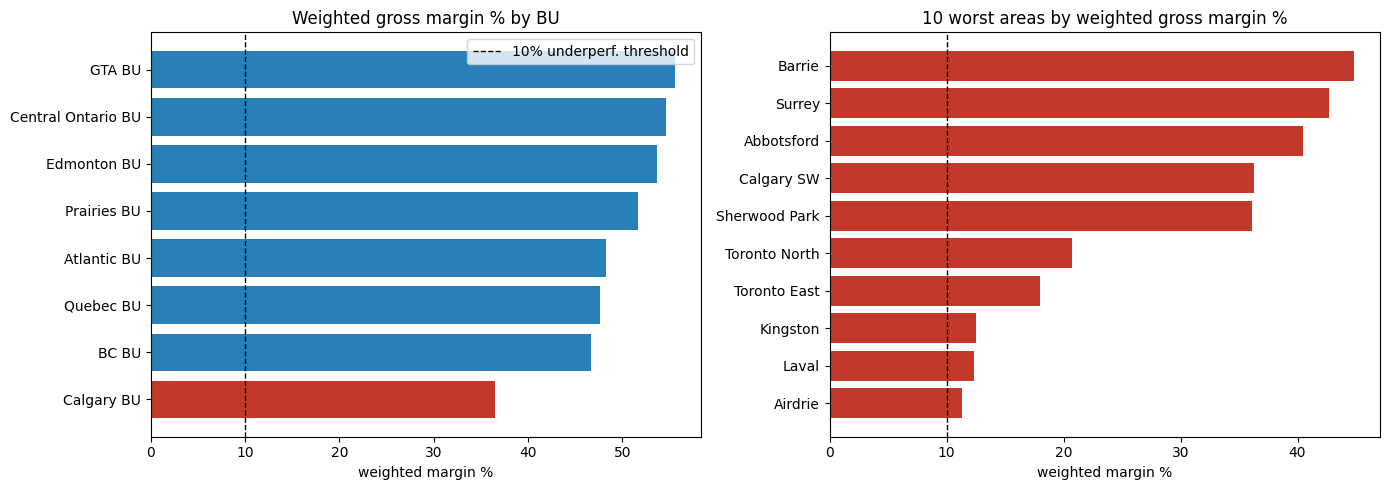

In [3]:
# CHART 1: BU weighted margin + worst-10 areas
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
b = bu_df.sort_values("weighted_margin")
c = ["#c0392b" if v < 40 else "#2980b9" for v in b["weighted_margin"]]
ax[0].barh(b["bu"], b["weighted_margin"], color=c)
ax[0].axvline(10, color="k", ls="--", lw=1, label="10% underperf. threshold")
ax[0].set_title("Weighted gross margin % by BU"); ax[0].set_xlabel("weighted margin %"); ax[0].legend()
a = area_df.head(10).sort_values("weighted_margin")
ax[1].barh(a["area"], a["weighted_margin"], color="#c0392b")
ax[1].axvline(10, color="k", ls="--", lw=1)
ax[1].set_title("10 worst areas by weighted gross margin %"); ax[1].set_xlabel("weighted margin %")
plt.tight_layout(); plt.savefig(f"{FIG}/01_underperformance_by_hierarchy.png", dpi=110, bbox_inches="tight")
plt.show()

## 2. Primary cost drivers behind low-margin route-days

Compare the cost-component **shares** and per-stop economics of `underperforming`
route-days vs the rest — actual averages, side by side. This isolates *what* makes
a bad day bad.

In [4]:
drivers = (silver.groupBy("underperforming_flag").agg(
    F.round(F.avg("disposal_cost_share"),3).alias("disposal_share"),
    F.round(F.avg("fuel_cost_share"),3).alias("fuel_share"),
    F.round(F.avg("labour_cost_share"),3).alias("labour_share"),
    F.round(F.avg("maintenance_cost_share"),3).alias("maintenance_share"),
    F.round(F.avg("admin_cost_share"),3).alias("admin_share"),
    F.round(F.avg("revenue_per_completed_stop"),2).alias("revenue_per_stop"),
    F.round(F.avg("cost_per_completed_stop"),2).alias("cost_per_stop"),
    F.round(F.avg("disposal_cost_per_tonne"),2).alias("disposal_per_tonne"),
    F.round(F.avg("completion_rate"),3).alias("completion_rate"),
).orderBy("underperforming_flag")).toPandas()
print(drivers.to_string(index=False))

healthy = drivers[~drivers.underperforming_flag].iloc[0]
under   = drivers[drivers.underperforming_flag].iloc[0]
print("\n--- deltas (underperforming vs healthy) ---")
print(f"disposal_share   : {under.disposal_share:.3f} vs {healthy.disposal_share:.3f}  (+{under.disposal_share-healthy.disposal_share:.3f})")
print(f"disposal_per_tonne: {under.disposal_per_tonne:.2f} vs {healthy.disposal_per_tonne:.2f}  (+{under.disposal_per_tonne-healthy.disposal_per_tonne:.2f})")
print(f"revenue_per_stop : {under.revenue_per_stop:.2f} vs {healthy.revenue_per_stop:.2f}  ({under.revenue_per_stop-healthy.revenue_per_stop:.2f})")
print(f"cost_per_stop    : {under.cost_per_stop:.2f} vs {healthy.cost_per_stop:.2f}  (+{under.cost_per_stop-healthy.cost_per_stop:.2f})")
print(f"completion_rate  : {under.completion_rate:.3f} vs {healthy.completion_rate:.3f}  (~equal -> NOT an ops/completion problem)")

 underperforming_flag  disposal_share  fuel_share  labour_share  maintenance_share  admin_share  revenue_per_stop  cost_per_stop  disposal_per_tonne  completion_rate
                False           0.581       0.067         0.230              0.023        0.099             62.33          29.30               59.17            0.985
                 True           0.747       0.044         0.155              0.015        0.039             36.10          38.28               82.59            0.985

--- deltas (underperforming vs healthy) ---
disposal_share   : 0.747 vs 0.581  (+0.166)
disposal_per_tonne: 82.59 vs 59.17  (+23.42)
revenue_per_stop : 36.10 vs 62.33  (-26.23)
cost_per_stop    : 38.28 vs 29.30  (+8.98)
completion_rate  : 0.985 vs 0.985  (~equal -> NOT an ops/completion problem)


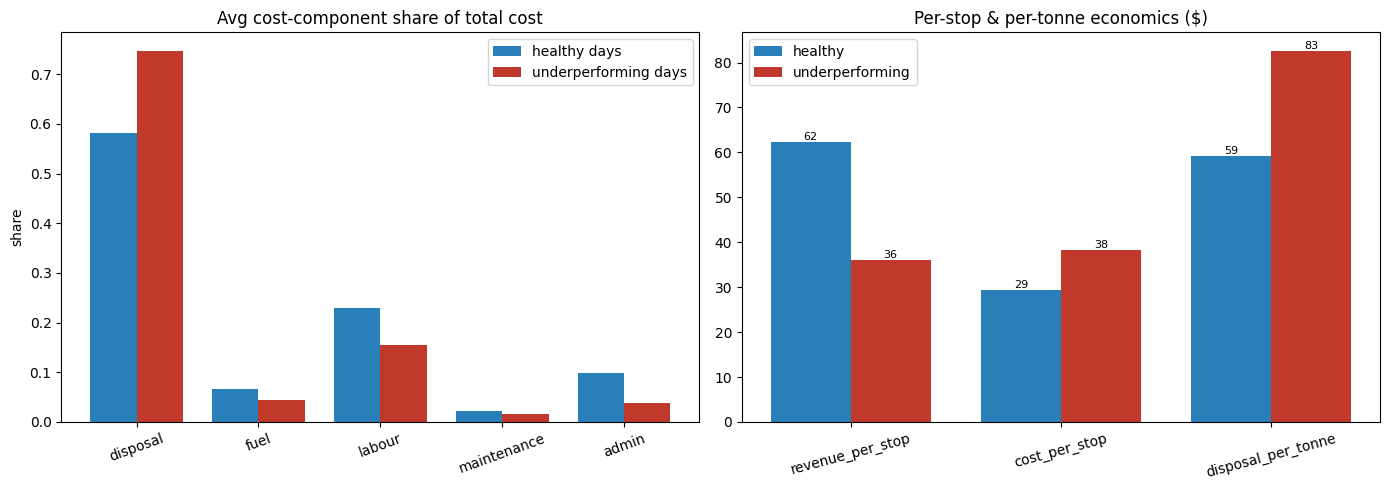

In [5]:
# CHART 2: cost-share comparison + per-stop economics
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
comps = ["disposal_share","fuel_share","labour_share","maintenance_share","admin_share"]
x = np.arange(len(comps)); w = 0.38
ax[0].bar(x-w/2, [healthy[c] for c in comps], w, label="healthy days", color="#2980b9")
ax[0].bar(x+w/2, [under[c]   for c in comps], w, label="underperforming days", color="#c0392b")
ax[0].set_xticks(x); ax[0].set_xticklabels([c.replace("_share","") for c in comps], rotation=20)
ax[0].set_title("Avg cost-component share of total cost"); ax[0].set_ylabel("share"); ax[0].legend()
labels=["revenue_per_stop","cost_per_stop","disposal_per_tonne"]
xx=np.arange(len(labels))
ax[1].bar(xx-w/2, [healthy[l] for l in labels], w, label="healthy", color="#2980b9")
ax[1].bar(xx+w/2, [under[l]   for l in labels], w, label="underperforming", color="#c0392b")
ax[1].set_xticks(xx); ax[1].set_xticklabels(labels, rotation=15)
ax[1].set_title("Per-stop & per-tonne economics ($)"); ax[1].legend()
for i,l in enumerate(labels):
    ax[1].text(i-w/2, healthy[l], f"{healthy[l]:.0f}", ha="center", va="bottom", fontsize=8)
    ax[1].text(i+w/2, under[l],   f"{under[l]:.0f}",   ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG}/02_cost_drivers.png", dpi=110, bbox_inches="tight"); plt.show()

In [6]:
# Supporting cut: margin by waste stream (the material-economics root cause)
ws = (silver.groupBy("primary_waste_stream").agg(
        F.round(F.sum("gross_profit")/F.sum("total_revenue")*100,2).alias("weighted_margin"),
        F.round(F.avg("disposal_cost_per_tonne"),2).alias("disposal_per_tonne"))
      .orderBy("weighted_margin")).toPandas()
print("=== Weighted margin by primary waste stream ==="); print(ws.to_string(index=False))

=== Weighted margin by primary waste stream ===
primary_waste_stream  weighted_margin  disposal_per_tonne
       General Waste            37.29               77.89
            Organics            43.53               55.27
           Recycling            73.02               32.21
           Cardboard            77.80               24.41


## 3. Three-year trend — improving or deteriorating?

Computed from **Gold** (route-month), aggregated to year. Weighted margin and
profit-per-stop are dollar-weighted across all route-months in the year.

In [7]:
trend = (gold.groupBy("year").agg(
    F.round(F.sum("gross_profit")/F.sum("total_revenue")*100,2).alias("weighted_margin"),
    F.round(F.sum("gross_profit")/F.sum("completed_stops"),2).alias("profit_per_stop"),
    F.round(F.sum("disposal_cost")/F.sum("total_tonnes"),2).alias("disposal_per_tonne"),
    F.round(F.sum(F.col("month_underperforming_flag").cast("int"))/F.count("*")*100,1).alias("under_month_pct"),
).orderBy("year")).toPandas()
print(trend.to_string(index=False))
d_m = trend.weighted_margin.iloc[-1]-trend.weighted_margin.iloc[0]
d_p = trend.profit_per_stop.iloc[-1]-trend.profit_per_stop.iloc[0]
print(f"\n2022->2024 weighted margin change : {d_m:+.2f} pts")
print(f"2022->2024 profit/stop change     : {d_p:+.2f} $/stop")
print("Direction:", "IMPROVING" if d_m>0 else "DETERIORATING")

 year  weighted_margin  profit_per_stop  disposal_per_tonne  under_month_pct
 2022            48.27            27.46               67.20              9.5
 2023            49.11            29.24               67.34              7.6
 2024            49.78            30.78               66.83              7.5

2022->2024 weighted margin change : +1.51 pts
2022->2024 profit/stop change     : +3.32 $/stop
Direction: IMPROVING


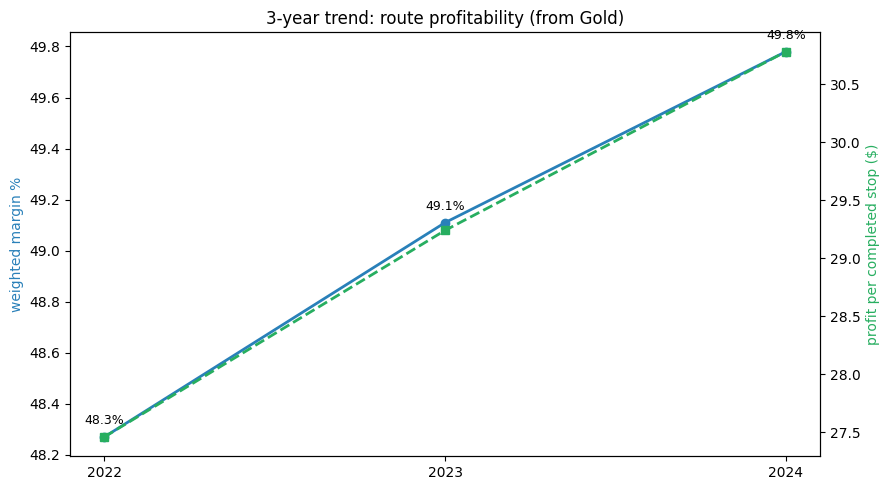

In [8]:
# CHART 3: trend (margin + profit-per-stop twin axis)
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(trend.year, trend.weighted_margin, "o-", color="#2980b9", lw=2, label="weighted margin %")
ax1.set_ylabel("weighted margin %", color="#2980b9"); ax1.set_xticks(trend.year)
ax2 = ax1.twinx()
ax2.plot(trend.year, trend.profit_per_stop, "s--", color="#27ae60", lw=2, label="profit per stop $")
ax2.set_ylabel("profit per completed stop ($)", color="#27ae60")
ax1.set_title("3-year trend: route profitability (from Gold)")
for x,y in zip(trend.year,trend.weighted_margin): ax1.text(x,y+0.05,f"{y:.1f}%",ha="center",fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/03_three_year_trend.png", dpi=110, bbox_inches="tight"); plt.show()

## 4. Worst area × segment pockets (basis for the recommendation)

=== Worst 10 area x segment pockets (>=30 days) ===
        area primary_customer_segment  days  weighted_margin  disposal_per_tonne  revenue_per_stop
 Fredericton      Office & Commercial   107           -13.00               77.11             31.32
     Airdrie      Office & Commercial    92             7.25               77.96             37.61
       Laval      Office & Commercial   200            12.37               79.18             41.70
    Kingston      Office & Commercial   102            12.52               78.66             41.79
      Regina      Office & Commercial   322            14.82               71.91             43.01
     Airdrie                   Retail    90            14.86               75.80             41.26
      Barrie      Office & Commercial   120            15.20               79.71             42.18
     Moncton                   Retail   194            17.06               65.15             43.44
Toronto East      Office & Commercial    96            17

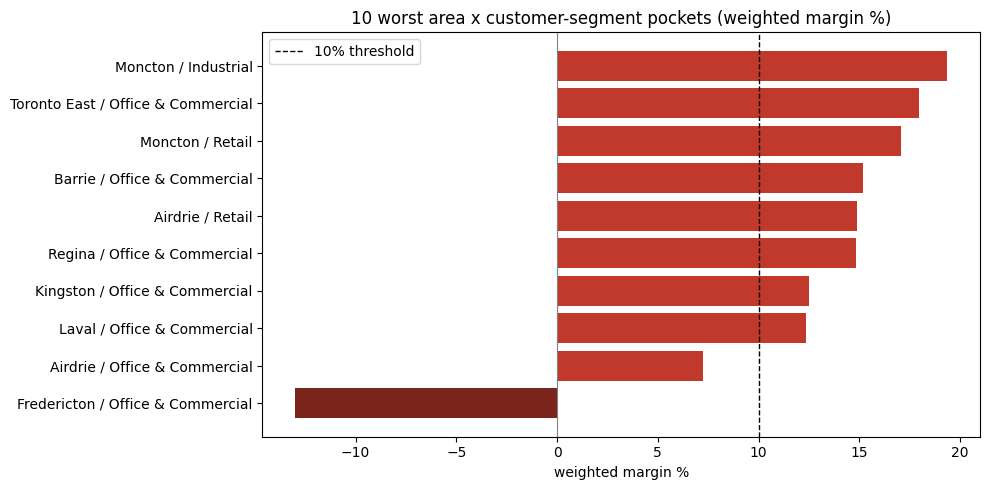

In [9]:
combo = (silver.groupBy("area","primary_customer_segment")
    .agg(F.count("*").alias("days"),
         F.round(F.sum("gross_profit")/F.sum("total_revenue")*100,2).alias("weighted_margin"),
         F.round(F.avg("disposal_cost_per_tonne"),2).alias("disposal_per_tonne"),
         F.round(F.avg("revenue_per_completed_stop"),2).alias("revenue_per_stop"))
    .filter("days >= 30").orderBy("weighted_margin")).toPandas()
print("=== Worst 10 area x segment pockets (>=30 days) ==="); print(combo.head(10).to_string(index=False))

# CHART 4: worst pockets
top = combo.head(10).sort_values("weighted_margin")
fig, ax = plt.subplots(figsize=(10,5))
lab = top.area + " / " + top.primary_customer_segment
col = ["#7b241c" if v<0 else "#c0392b" for v in top.weighted_margin]
ax.barh(lab, top.weighted_margin, color=col)
ax.axvline(10, color="k", ls="--", lw=1, label="10% threshold"); ax.axvline(0,color="gray",lw=0.8)
ax.set_title("10 worst area x customer-segment pockets (weighted margin %)")
ax.set_xlabel("weighted margin %"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/04_worst_pockets.png", dpi=110, bbox_inches="tight"); plt.show()

## Findings & recommendation (written from the numbers above)

**What the data says (all figures from cells above):**

1. **Underperformance is concentrated, not diffuse.** At the BU level **Calgary BU**
   is the clear laggard (~36.5% weighted margin, ~15% of its days flagged) while
   every other BU sits 46–56%. The pain sharpens by area: **Airdrie (~11.3%), Laval
   (~12.4%), Kingston (~12.5%)** run barely above the 10% floor with ~half their
   days underperforming. **21 of 120 routes** are persistent structural
   underperformers.

2. **The driver is material economics + underpricing — NOT crew productivity.** On
   underperforming days, disposal is **74.7%** of total cost vs **58.1%** on healthy
   days, and **disposal-per-tonne is $82.6 vs $59.2** (+40%). At the same time
   **revenue-per-stop collapses to $36.1 vs $62.3** while **cost-per-stop rises to
   $38.3 vs $29.3** — so a bad route-day bills *less* per stop than it costs.
   Critically, **completion_rate is identical (0.985)** in both groups: these routes
   aren't missing stops or running late, they are **hauling heavy low-value material
   to expensive tips at prices that don't cover the gate fee.** By stream, **General
   Waste (37.3% margin, $77.9/tonne disposal)** is the drag; Cardboard/Recycling
   clear 73–78%.

3. **Trend is gently improving, not deteriorating.** From Gold: weighted margin
   **48.3% → 49.1% → 49.8%** (2022→2024) and profit-per-stop **$27.5 → $30.8**.
   Disposal-per-tonne is flat (~$67). So the *fleet overall* is healing slowly — but
   the worst pockets above are not; they're being masked by the healthy majority.

4. **Worst pockets are a specific segment:** **Office & Commercial** dominates the
   worst area×segment list — **Fredericton / Office & Commercial is actually
   negative (−13.0% weighted margin)**, followed by Airdrie, Laval, Kingston,
   Regina — all Office & Commercial.

**Recommendation for next quarter (specific, data-backed):**

> **Re-price and re-route the Office & Commercial / General-Waste book in Calgary BU
> (Airdrie) and the Fredericton, Laval, Kingston, Regina areas — the ~21 persistent
> routes.** These route-days collect heavy General Waste at **~$83/tonne disposal**
> but bill only **~$36/stop**, below their **~$38/stop cost** — a structural pricing
> gap, since completion is already at 98.5% (no productivity slack left to cut).
> Three concrete moves, in priority order:
> 1. **Pass through a disposal surcharge / re-rate** the Office & Commercial General-
>    Waste contracts in these areas to close the $36→$38 per-stop gap (target the
>    10% margin floor first, then BU median ~47%).
> 2. **Divert recoverable material** (cardboard/recycling clear 73–78% margin) out of
>    the General-Waste stream on these routes to cut tonnage to the expensive tip.
> 3. **Consolidate the low-density Airdrie/Fredericton route-days** (revenue-per-stop
>    is half the fleet norm) to lift stops-per-route before the next pricing cycle.
>
> Expected effect: lifting just the 21 persistent routes from sub-10% to the ~47% BU
> median is where the recoverable margin sits — and it's a pricing/material problem
> the ops + commercial teams can act on directly, not a service-quality fix.

In [10]:
spark.stop()
print("Spark stopped.")

Spark stopped.
